<a href="https://colab.research.google.com/github/anaalusouto/ProcessamentoDeImagens/blob/main/atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processamento Digital de Imagens: Histogramas

Análise e processamento de três imagens pessoais: **escura**, **clara** e **bem exposta**.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [1]:
def corrigir_gamma(img, gamma=1.0):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

def expandir_contraste(img, L=0, H=255):
    img_f = img.astype(np.float32)
    mn, mx = np.min(img_f), np.max(img_f)
    if mx == mn: return img
    out = (img_f - mn) / (mx - mn) * (H - L) + L
    return np.clip(out, L, H).astype(np.uint8)

def mostrar_resultado(orig, proc, titulo_orig, titulo_proc):
    fig, ax = plt.subplots(2, 2, figsize=(10, 6))

    ax[0, 0].imshow(orig, cmap='gray')
    ax[0, 0].set_title(titulo_orig)
    ax[0, 0].axis('off')

    ax[0, 1].imshow(proc, cmap='gray')
    ax[0, 1].set_title(titulo_proc)
    ax[0, 1].axis('off')

    ax[1, 0].hist(orig.ravel(), bins=256, range=[0, 256], color='gray')
    ax[1, 0].set_title('Histograma Antes')
    ax[1, 0].set_xlim([0, 256])

    ax[1, 1].hist(proc.ravel(), bins=256, range=[0, 256], color='black')
    ax[1, 1].set_title('Histograma Depois')
    ax[1, 1].set_xlim([0, 256])

    plt.tight_layout()
    plt.show()

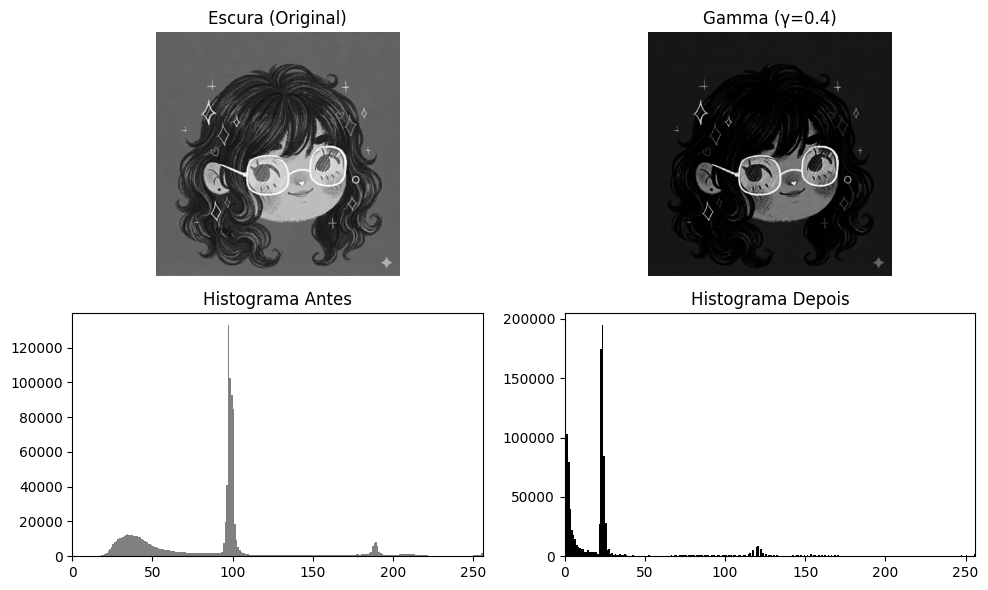

In [3]:
img_escura = cv2.imread('celula.jpeg', cv2.IMREAD_GRAYSCALE)

gamma = 0.4
img_escura_proc = corrigir_gamma(img_escura, gamma=gamma)

mostrar_resultado(img_escura, img_escura_proc, 'Escura (Original)', f'Gamma (γ={gamma})')

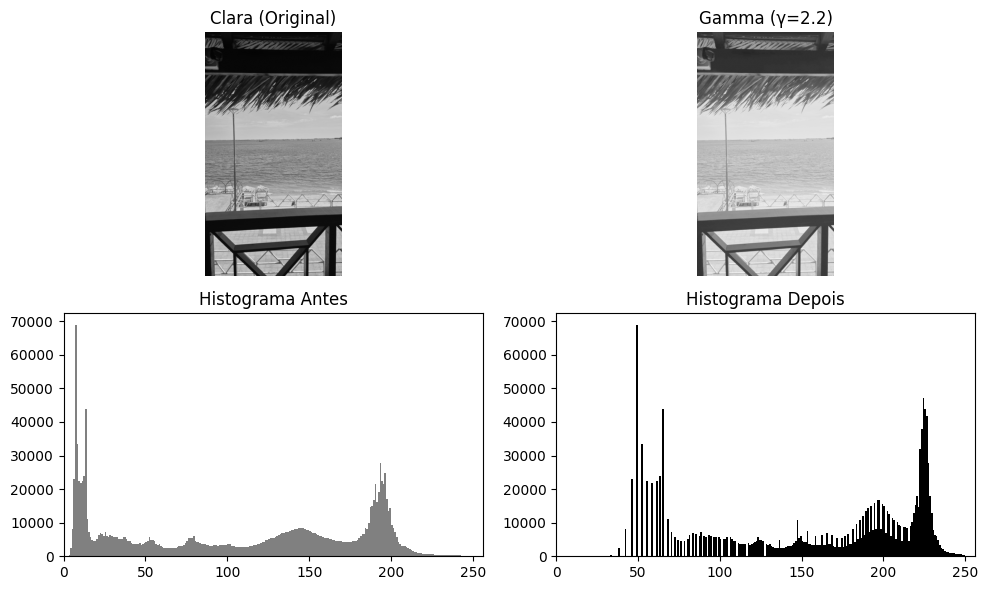

In [4]:
img_clara = cv2.imread('alter.jpeg', cv2.IMREAD_GRAYSCALE)

gamma = 2.2
img_clara_proc = corrigir_gamma(img_clara, gamma=gamma)

mostrar_resultado(img_clara, img_clara_proc, 'Clara (Original)', f'Gamma (γ={gamma})')

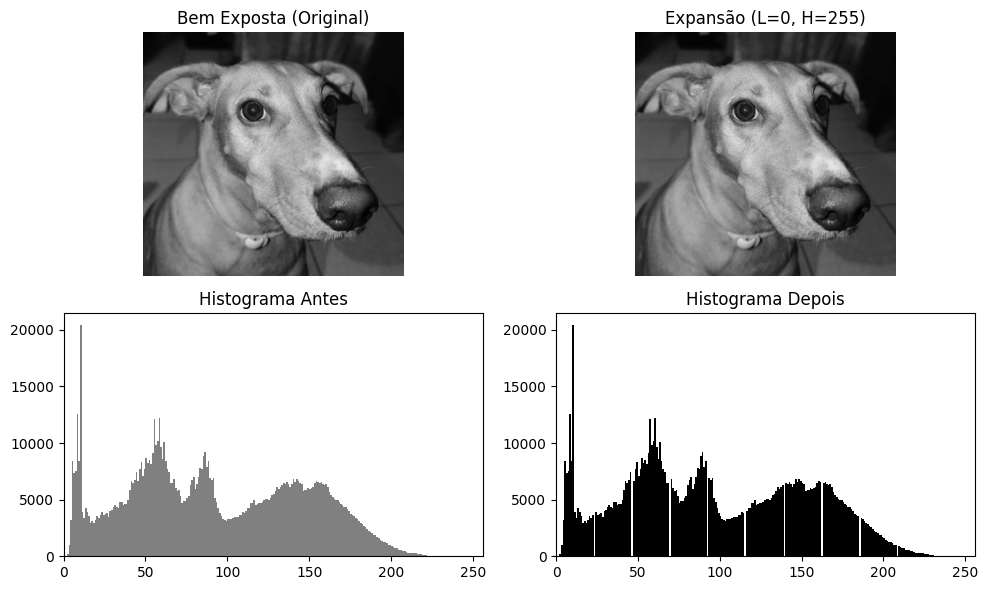

In [6]:
img_boa = cv2.imread('auau.jpeg', cv2.IMREAD_GRAYSCALE)

L, H = 0, 255
img_boa_proc = expandir_contraste(img_boa, L=L, H=H)

mostrar_resultado(img_boa, img_boa_proc, 'Bem Exposta (Original)', f'Expansão (L={L}, H={H})')

## Resposta Final

**Em qual das três imagens a operação fez menos diferença? Por quê?**

A operação fez menos diferença na **imagem bem exposta**. Isso ocorre porque o seu histograma original já possuía uma ampla distribuição de pixels cobrindo quase toda a faixa de cinza (de 0 a 255), caracterizando um bom contraste natural. Como o menor valor já estava próximo de 0 e o maior valor próximo de 255, a expansão de contraste alterou muito pouco os valores dos pixels. Já nas imagens escura e clara, o ajuste de Gamma redistribuiu intensidades que estavam acumuladas nos extremos, gerando uma mudança visual muito mais visível.